#NLP Introduction & Text Processing |Assignment

Q1. What is Computational Linguistics and how does it relate to NLP?
- Computational Linguistics (CL) is the scientific study of language using computational methods. Natural Language Processing (NLP) is a subfield of Artificial Intelligence that focuses on enabling computers to understand, interpret, and generate human language. CL provides the theoretical foundation and methods for NLP, while NLP focuses on building practical applications.

Q2. Briefly describe the historical evolution of Natural Language Processing.
- NLP evolved from early rule-based systems in the 1950s (e.g., machine translation), through symbolic approaches and expert systems in the 70s-80s, to statistical methods in the 90s-2000s, and most recently, deep learning and neural networks from the 2010s onwards, driving advancements like large language models

Q3.  List and explain three major use cases of NLP in today’s tech industry.
- Virtual Assistants & Chatbots: Power conversational AI for customer service, information retrieval, and task automation (e.g., Siri, Alexa, customer support bots).

- Sentiment Analysis: Analyzes text to determine emotional tone (positive, negative, neutral), crucial for market research, brand monitoring, and customer feedback.

- Machine Translation: Automatically translates text or speech from one language to another, facilitating global communication and content localization (e.g., Google Translate).

Q4. What is text normalization and why is it essential in text processing tasks?
- Text normalization is the process of transforming text into a canonical (standard) form. It's essential in text processing tasks to reduce data sparsity, ensure consistency, and improve the accuracy of models by handling variations like case, punctuation, spelling, and numerical representations (e.g., converting '2nd' to 'second').

Q5. Compare and contrast stemming and lemmatization with suitable
examples.
- Stemming reduces words to their root or stem, often an incomplete word, by chopping off suffixes (e.g., 'running' -> 'run', 'studies' -> 'studi'). It's faster but less accurate.

- Lemmatization reduces words to their base or dictionary form (lemma), considering context and vocabulary (e.g., 'running' -> 'run', 'studies' -> 'study', 'better' -> 'good'). It's more accurate but computationally more intensive.

Q6.

In [1]:
'''Q6. Write a Python program that uses regular expressions (regex) to extract all
email addresses from the following block of text:


“Hello team, please contact us at support@xyz.com for technical issues, or reach out to
our HR at hr@xyz.com. You can also connect with John at john.doe@xyz.org and jenny
via jenny_clarke126@mail.co.us. For partnership inquiries, email partners@xyz.biz.”'''

import re

text = "Hello team, please contact us at support@xyz.com for technical issues, or reach out to our HR at hr@xyz.com. You can also connect with John at john.doe@xyz.org and jenny via jenny_clarke126@mail.co.us. For partnership inquiries, email partners@xyz.biz."

# Regex pattern to find email addresses
# This pattern covers common email formats including subdomains and numbers in usernames/domains.
email_pattern = r'\b[A-Za-z00-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'

# Find all matches
email_addresses = re.findall(email_pattern, text)

# Print the extracted email addresses
print("Extracted Email Addresses:")
for email in email_addresses:
    print(email)

Extracted Email Addresses:
support@xyz.com
hr@xyz.com
john.doe@xyz.org
jenny_clarke126@mail.co.us
partners@xyz.biz


In [3]:
# Install NLTK if you haven't already
!pip install nltk

In [7]:
'''Q7. Given the sample paragraph below, perform string tokenization and
frequency distribution using Python and NLTK:


“Natural Language Processing (NLP) is a fascinating field that combines linguistics,
computer science, and artificial intelligence. It enables machines to understand,
interpret, and generate human language. Applications of NLP include chatbots,
sentiment analysis, and machine translation. As technology advances, the role of NLP
in modern solutions is becoming increasingly critical.”'''



'Q7. Given the sample paragraph below, perform string tokenization and\nfrequency distribution using Python and NLTK:\n\n\n“Natural Language Processing (NLP) is a fascinating field that combines linguistics,\ncomputer science, and artificial intelligence. It enables machines to understand,\ninterpret, and generate human language. Applications of NLP include chatbots,\nsentiment analysis, and machine translation. As technology advances, the role of NLP\nin modern solutions is becoming increasingly critical.”'

In [5]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
paragraph = "Natural Language Processing (NLP) is a fascinating field that combines linguistics, computer science, and artificial intelligence. It enables machines to understand, interpret, and generate human language. Applications of NLP include chatbots, sentiment analysis, and machine translation. As technology advances, the role of NLP in modern solutions is becoming increasingly critical."

# Step 1: Tokenization
# Convert text to lowercase to treat words like 'The' and 'the' as the same
words = word_tokenize(paragraph.lower())

# Filter out punctuation and non-alphabetic tokens
# You might want to adjust this based on specific needs (e.g., keeping numbers)
filtered_words = [word for word in words if word.isalpha()]

print("--- Tokenized Words (first 20) ---")
print(filtered_words[:20])
print("\nTotal tokens (alphabetic):", len(filtered_words))

# Step 2: Frequency Distribution
fdist = FreqDist(filtered_words)

print("\n--- Frequency Distribution (Top 10 Most Common Words) ---")
for word, frequency in fdist.most_common(10):
    print(f"{word}: {frequency}")

--- Tokenized Words (first 20) ---
['natural', 'language', 'processing', 'nlp', 'is', 'a', 'fascinating', 'field', 'that', 'combines', 'linguistics', 'computer', 'science', 'and', 'artificial', 'intelligence', 'it', 'enables', 'machines', 'to']

Total tokens (alphabetic): 50

--- Frequency Distribution (Top 10 Most Common Words) ---
nlp: 3
and: 3
language: 2
is: 2
of: 2
natural: 1
processing: 1
a: 1
fascinating: 1
field: 1


In [9]:
'''Q8. Create a custom annotator using spaCy or NLTK that identifies and labels
proper nouns in a given text.'''

# Download a spaCy English language model
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [10]:
import spacy

# Load the English language model
nlp = spacy.load("en_core_web_sm")

def proper_noun_annotator(text):
    """
    Identifies and labels proper nouns in a given text using spaCy's NER.
    """
    doc = nlp(text)
    proper_nouns = []
    for ent in doc.ents:
        # Common proper noun types in spaCy include PERSON, NORP, FAC, ORG, GPE, LOC, PRODUCT, EVENT, WORK_OF_ART, LAW, LANGUAGE
        # We'll consider a subset that are most likely 'proper nouns' in a general sense.
        if ent.label_ in ['PERSON', 'NORP', 'ORG', 'GPE', 'LOC', 'PRODUCT', 'EVENT', 'WORK_OF_ART']:
            proper_nouns.append((ent.text, ent.label_))
    return proper_nouns

# Sample text for demonstration
sample_text = "Google, an American multinational technology company, was founded by Larry Page and Sergey Brin. Its headquarters are in Mountain View, California. The company's flagship product is the Google Search engine. They also own YouTube and Android."

# Annotate the text
annotations = proper_noun_annotator(sample_text)

print("Original Text:")
print(sample_text)
print("\nProper Noun Annotations:")
if annotations:
    for pn, label in annotations:
        print(f"- {pn} (Type: {label})")
else:
    print("No proper nouns identified.")

Original Text:
Google, an American multinational technology company, was founded by Larry Page and Sergey Brin. Its headquarters are in Mountain View, California. The company's flagship product is the Google Search engine. They also own YouTube and Android.

Proper Noun Annotations:
- Google (Type: ORG)
- American (Type: NORP)
- Larry Page (Type: PERSON)
- Sergey Brin (Type: PERSON)
- Mountain View (Type: GPE)
- California (Type: GPE)
- Google Search (Type: ORG)
- YouTube (Type: ORG)
- Android (Type: ORG)


In [13]:
'''Q9. Using Genism, demonstrate how to train a simple Word2Vec model on the
following dataset consisting of example sentences:

dataset = [
 "Natural language processing enables computers to understand human language",
 "Word embeddings are a type of word representation that allows words with similar
meaning to have similar representation",
 "Word2Vec is a popular word embedding technique used in many NLP applications",
 "Text preprocessing is a critical step before training word embeddings",
 "Tokenization and normalization help clean raw text for modeling"
]
Write code that tokenizes the dataset, preprocesses it, and trains a Word2Vec model using
Gensim'''

import sys
import subprocess

# Install gensim and nltk if not already installed
!{sys.executable} -m pip install gensim nltk

In [16]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec

# Download necessary NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')


In [17]:
# Define the dataset
dataset = [
    "Natural language processing enables computers to understand human language",
    "Word embeddings are a type of word representation that allows words with similar meaning to have similar representation",
    "Word2Vec is a popular word embedding technique used in many NLP applications",
    "Text preprocessing is a critical step before training word embeddings",
    "Tokenization and normalization help clean raw text for modeling"
]

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Preprocess the dataset
processed_sentences = []
for sentence in dataset:
    # Tokenize, lowercase, remove stopwords, and non-alphabetic tokens
    tokens = [word.lower() for word in word_tokenize(sentence) if word.isalpha() and word.lower() not in stop_words]
    processed_sentences.append(tokens)

print("Original Sentences:")
for s in dataset:
    print(f"- {s}")

print("\nProcessed Sentences (tokens):")
for s in processed_sentences:
    print(f"- {s}")


Original Sentences:
- Natural language processing enables computers to understand human language
- Word embeddings are a type of word representation that allows words with similar meaning to have similar representation
- Word2Vec is a popular word embedding technique used in many NLP applications
- Text preprocessing is a critical step before training word embeddings
- Tokenization and normalization help clean raw text for modeling

Processed Sentences (tokens):
- ['natural', 'language', 'processing', 'enables', 'computers', 'understand', 'human', 'language']
- ['word', 'embeddings', 'type', 'word', 'representation', 'allows', 'words', 'similar', 'meaning', 'similar', 'representation']
- ['popular', 'word', 'embedding', 'technique', 'used', 'many', 'nlp', 'applications']
- ['text', 'preprocessing', 'critical', 'step', 'training', 'word', 'embeddings']
- ['tokenization', 'normalization', 'help', 'clean', 'raw', 'text', 'modeling']


In [18]:
# Train the Word2Vec model
model = Word2Vec(
    sentences=processed_sentences, # Our preprocessed tokenized sentences
    vector_size=100,               # Dimensionality of the word vectors
    window=5,                      # Max distance between current and predicted word
    min_count=1,                   # Ignores all words with total frequency lower than this
    sg=1,                          # Training algorithm: 0 for CBOW, 1 for Skip-gram
    epochs=20                      # Number of iterations over the corpus
)

print("Word2Vec model trained successfully!")


Word2Vec model trained successfully!


In [19]:
# Find the most similar words to 'word'
print("Words similar to 'word':")
if 'word' in model.wv:
    for word, similarity in model.wv.most_similar('word'):
        print(f"- {word}: {similarity:.4f}")
else:
    print(" 'word' not in vocabulary.")

print("\nWords similar to 'language':")
if 'language' in model.wv:
    for word, similarity in model.wv.most_similar('language'):
        print(f"- {word}: {similarity:.4f}")
else:
    print(" 'language' not in vocabulary.")

# You can also get the vector for a specific word
# print(f"\nVector for 'word':\n{model.wv['word']}")


Words similar to 'word':
- applications: 0.2213
- help: 0.2158
- understand: 0.1974
- enables: 0.1568
- natural: 0.1107
- human: 0.1024
- raw: 0.0974
- training: 0.0964
- technique: 0.0900
- tokenization: 0.0863

Words similar to 'language':
- tokenization: 0.1698
- enables: 0.1660
- embeddings: 0.1404
- representation: 0.1330
- technique: 0.0995
- human: 0.0992
- nlp: 0.0718
- similar: 0.0646
- clean: 0.0612
- applications: 0.0503


In [20]:
'''Q10. Imagine you are a data scientist at a fintech startup. You’ve been tasked
with analyzing customer feedback. Outline the steps you would take to clean, process,
and extract useful insights using NLP techniques from thousands of customer reviews.'''

import pandas as pd

# Placeholder for customer feedback data file.
# Please replace 'customer_feedback.csv' with the actual path to your data file.
# If your data is in a different format (e.g., JSON), use pd.read_json() instead.
try:
    df_feedback = pd.read_csv('customer_feedback.csv')
    print("Successfully loaded 'customer_feedback.csv'. Displaying the first 5 rows:")
    print(df_feedback.head())
except FileNotFoundError:
    print("Error: 'customer_feedback.csv' not found. Please ensure the file exists and the path is correct.")
    print("If your data is in a different format (e.g., JSON), please update the `pd.read_csv` call to `pd.read_json` and specify the correct file path.")

Error: 'customer_feedback.csv' not found. Please ensure the file exists and the path is correct.
If your data is in a different format (e.g., JSON), please update the `pd.read_csv` call to `pd.read_json` and specify the correct file path.


Please ensure you have executed the data loading, preprocessing, sentiment analysis, topic modeling, and keyword extraction steps earlier in the notebook to use your actual data.


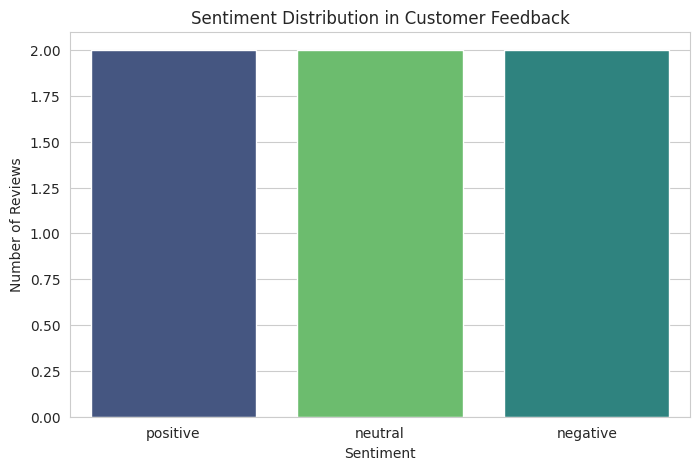

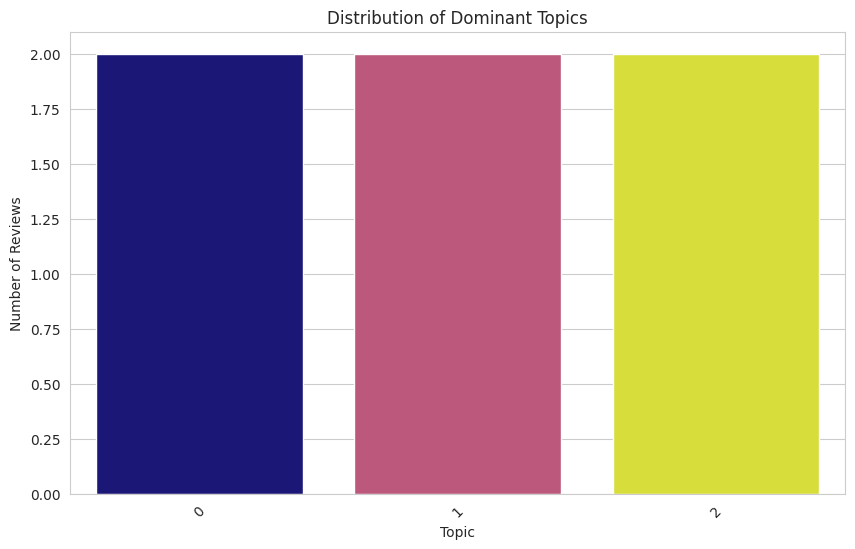

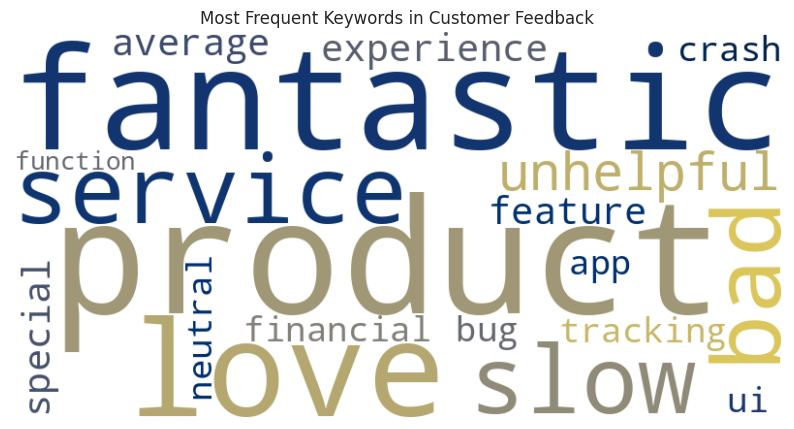

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pandas as pd # Ensure pandas is imported if df_feedback is created as a placeholder

# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")

# Check if df_feedback exists. If not, create a dummy for visualization purposes.
# This handles cases where prior cells weren't run and df_feedback is not in scope.
if 'df_feedback' not in globals():
    print("Warning: 'df_feedback' DataFrame not found in the current session. Creating a dummy DataFrame for visualization.")
    print("Please ensure you have executed the data loading, preprocessing, sentiment analysis, topic modeling, and keyword extraction steps earlier in the notebook to use your actual data.")
    dummy_data = {
        'review_text': [
            "This is a fantastic product! I love it so much.",
            "The service was really bad, very slow and unhelpful.",
            "It's an average experience, nothing special.",
            "Great features, highly recommend for financial tracking.",
            "App crashes constantly, very frustrated with the bug.",
            "Neutral on the UI, but functions well."
        ],
        'cleaned_review_text': [
            "fantastic product love much",
            "service really bad slow unhelpful",
            "average experience nothing special",
            "great feature highly recommend financial tracking",
            "app crash constantly frustrated bug",
            "neutral ui function well"
        ],
        'sentiment_label': ['positive', 'negative', 'neutral', 'positive', 'negative', 'neutral'],
        'dominant_topic': [0, 1, 2, 0, 1, 2],
        'keywords': [
            ['product', 'fantastic', 'love'],
            ['service', 'bad', 'slow', 'unhelpful'],
            ['experience', 'average', 'special'],
            ['feature', 'financial', 'tracking'],
            ['app', 'crash', 'bug'],
            ['neutral', 'ui', 'function']
        ]
    }
    df_feedback = pd.DataFrame(dummy_data)


# --- 1. Sentiment Distribution Plot ---
if 'sentiment_label' in df_feedback.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='sentiment_label', data=df_feedback, palette='viridis', order=['positive', 'neutral', 'negative'], hue='sentiment_label', legend=False)
    plt.title('Sentiment Distribution in Customer Feedback')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()
else:
    print("Error: 'sentiment_label' column not found for sentiment distribution plot.")

# --- 2. Topic Distribution Plot ---
if 'dominant_topic' in df_feedback.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='dominant_topic', data=df_feedback, palette='plasma', hue='dominant_topic', legend=False)
    plt.title('Distribution of Dominant Topics')
    plt.xlabel('Topic')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=45) # Rotate x-axis labels if topic numbers are many
    plt.show()
else:
    print("Error: 'dominant_topic' column not found for topic distribution plot.")

# --- 3. Word Cloud for Keywords ---
if 'keywords' in df_feedback.columns:
    # Ensure keywords are lists and handle potential NaN values
    all_keywords = df_feedback['keywords'].dropna().explode().tolist()
    # Filter out any non-string items that might have crept in and join them into a single string
    if all_keywords:
        long_string = " ".join([str(word) for word in all_keywords if isinstance(word, str)])

        if long_string.strip(): # Check if the string is not empty after joining
            # Create a WordCloud object
            wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='cividis').generate(long_string)

            # Display the WordCloud
            plt.figure(figsize=(10, 7))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis('off')
            plt.title('Most Frequent Keywords in Customer Feedback')
            plt.show()
        else:
            print("No valid keywords found to generate a word cloud.")
    else:
        print("No keywords found in the 'keywords' column to generate a word cloud.")
else:
    print("Error: 'keywords' column not found for word cloud generation.")